<a href="https://colab.research.google.com/github/noambar2910/EDA-Online-Sales-HW1/blob/main/EDA_Online_Sales_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# מטלה 1: ניתוח נתונים חקרני (EDA)
## ניתוח חקרני של נתוני מכירות אונליין בחנות E-Commerce

שם הסטודנט: ____נועם בר______  
מספר זהות: ___322333493_______  
קורס: מבוא למדעי הנתונים  
מרצה: ד"ר אורי איתי  
מתרגלת: גבריאלה וגנר  
תאריך הגשה: 7.5.2026

## 1. מטרת המטלה

מטרת העבודה היא לבצע ניתוח נתונים חקרני ראשוני למערך נתונים מתחום המכירות המקוונות. במסגרת הניתוח נבחן את מבנה הנתונים, איכותם, שלמותם, סוגי המשתנים, דפוסי התפלגות, קשרים בין משתנים ותובנות מרכזיות שעולות מהנתונים.

העבודה מתמקדת בהבנת הנתונים מעבר להצגה בסיסית של גרפים, תוך התייחסות למבנה הפנימי של הנתונים, להנחות סמויות, למגבלות אפשריות ולהטיות שעשויות לנבוע מאופן איסוף הנתונים.

## 2. בחירת מערך נתונים

### 2.1 דרישות

מערך הנתונים שנבחר הוא **Shop Direct Sale Data For Research**.

הנתונים עוסקים במכירות של חנות אונליין וכוללים פרטים על הזמנות, לקוחות, אזורים גאוגרפיים, קטגוריות מוצרים, אופן משלוח, כמות, עלות, רווח ומכירות.

הדאטהסט עומד בדרישות המטלה:

| דרישה | האם מתקיים? |
|---|---|
| מידע טבלאי | כן |
| לפחות 1000 שורות | כן |
| לפחות 10 עמודות | כן |
| משתנים מספריים | כן: Quantity, Cost, Profit, Sales |
| משתנים קטגוריאליים | כן: Country, Region, Segment, Category, Ship Mode ועוד |
| משתנה זמן | כן: Order Date |

### 2.2 תיאור מקור הנתונים

מקור הנתונים הוא אתר Kaggle, מתוך דאטהסט בשם **Shop Direct Sale E-Commerce Dataset**. הנתונים כוללים רשומות של מכירות, לקוחות, מוצרים, מדינות, אזורים, עלויות, רווחים וסכומי מכירה.

מטרת איסוף הנתונים היא לאפשר ניתוח של פעילות מכירה בחנות אונליין. ניתן להשתמש בנתונים כדי להבין דפוסי רכישה, לזהות קטגוריות רווחיות, לבחון אזורים גאוגרפיים חזקים יותר ולבדוק קשרים בין משתנים כמו כמות, עלות, רווח ומכירות.


## טעינת ספריות והנתונים

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרות תצוגה
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url =" https://raw.githubusercontent.com/noambar2910/EDA-Online-Sales-HW1/refs/heads/main/Shop%20Direct%20Sale%20Data%20For%20Research.csv"
df = pd.read_csv(url)

df.head()

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales
0,1,1/1/2017,Ruby Patel,Stockholm,Sweden,Stockholm,North,Home Office,Office Supplies,Economy Plus,Paper,"Enermax Note Cards, Premium",3,9,36,45
1,2,1/3/2017,Summer Hayward,Southport,United Kingdom,England,North,Consumer,Furniture,Economy,Bookcases,"Dania Corner Shelving, Traditional",7,255,599,854
2,3,1/4/2017,Devin Huddleston,Valence,France,Auvergne-Rhône-Alpes,Central,Consumer,Office Supplies,Economy,Art,"Binney & Smith Sketch Pad, Easy-Erase",3,48,92,140
3,4,1/4/2017,Mary Parker,Birmingham,United Kingdom,England,North,Corporate,Office Supplies,Economy,Art,"Boston Markers, Easy-Erase",2,9,18,27
4,5,1/5/2017,Daniel Burke,Echirolles,France,Auvergne-Rhône-Alpes,Central,Home Office,Office Supplies,Priority,Art,"Binney & Smith Pencil Sharpener, Water Color",3,40,50,90


In [59]:

file_name = "Shop Direct Sale Data For Research.csv"
df = pd.read_csv(file_name)

# הצגת 5 השורות הראשונות
df.head()

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales
0,1,1/1/2017,Ruby Patel,Stockholm,Sweden,Stockholm,North,Home Office,Office Supplies,Economy Plus,Paper,"Enermax Note Cards, Premium",3,9,36,45
1,2,1/3/2017,Summer Hayward,Southport,United Kingdom,England,North,Consumer,Furniture,Economy,Bookcases,"Dania Corner Shelving, Traditional",7,255,599,854
2,3,1/4/2017,Devin Huddleston,Valence,France,Auvergne-Rhône-Alpes,Central,Consumer,Office Supplies,Economy,Art,"Binney & Smith Sketch Pad, Easy-Erase",3,48,92,140
3,4,1/4/2017,Mary Parker,Birmingham,United Kingdom,England,North,Corporate,Office Supplies,Economy,Art,"Boston Markers, Easy-Erase",2,9,18,27
4,5,1/5/2017,Daniel Burke,Echirolles,France,Auvergne-Rhône-Alpes,Central,Home Office,Office Supplies,Priority,Art,"Binney & Smith Pencil Sharpener, Water Color",3,40,50,90


## 3. מטא-אנליזה של הנתונים

### 3.1 ניתוח הקובץ

שם הקובץ: **Shop Direct Sale Data For Research.csv**  
פורמט הקובץ: **CSV**  
מטרת הנתונים: הנתונים מתארים עסקאות מכירה בחנות אונליין. כל שורה בטבלה מייצגת רשומת מכירה, וכוללת מידע על מועד ההזמנה, הלקוח, המיקום הגאוגרפי, סוג הלקוח, קטגוריית המוצר, אופן המשלוח, כמות, עלות, רווח וסך המכירה.

In [60]:
import os

file_size_kb = os.path.getsize(file_name) / 1024
file_size_kb

616.7177734375

In [61]:
# מספר שורות ועמודות
df.shape

(4115, 16)

### 3.2 מבנה הנתונים

בשלב זה נבדוק את מבנה הטבלה: מספר שורות ועמודות, שמות עמודות, סוגי נתונים ואינדקס.

In [62]:
# שמות העמודות
df.columns.tolist()

['Order ID',
 'Order Date',
 'Customer Name',
 'City',
 'Country',
 'State',
 'Region',
 'Segment',
 'Category',
 'Ship Mode',
 'Sub-Category',
 'Product Name',
 'Quantity',
 'Cost',
 'Profit',
 'Sales']

In [63]:
# סוגי נתונים
atypes = df.dtypes.reset_index()
atypes.columns = ["Column", "Data Type"]
atypes

,Column,Data Type
0,Order ID,int64
1,Order Date,object
2,Customer Name,object
3,City,object
4,Country,object
5,State,object
6,Region,object
7,Segment,object
8,Category,object
9,Ship Mode,object


In [64]:

# הנתונים בקובץ הם בפורמט חודש/יום/שנה
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")

# בדיקת טווח תאריכים
df["Order Date"].min(), df["Order Date"].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2020-12-31 00:00:00'))

In [65]:
# בדיקת אינדקס ומזהה הזמנה
df.index.is_unique, df["Order ID"].is_unique

(True, True)

#### ניתוח ראשוני של מבנה הנתונים

שמות העמודות ברורים יחסית ומתארים את סוג המידע שמופיע בכל עמודה. ניתן ללמוד מכך שהנתונים מאורגנים סביב עסקאות מכירה: יש מזהה הזמנה, תאריך הזמנה, פרטי לקוח ומיקום, פרטי מוצר, ואינדיקטורים כספיים.


## 4. איכות ושלמות הנתונים

### 4.1 נתונים חסרים

In [66]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percent": (df.isnull().sum() / len(df)) * 100
})
missing_table

,Missing Values,Missing Percent
Order ID,0,0.00
Order Date,0,0.00
Customer Name,0,0.00
City,0,0.00
Country,0,0.00
State,0,0.00
Region,0,0.00
Segment,0,0.00
Category,0,0.00
Ship Mode,0,0.00


#### ניתוח נתונים חסרים

בבדיקה נמצא כי אין ערכים חסרים באף אחת מהעמודות. לכן היקף החוסר הוא 0%, ולא ניתן לזהות דפוס של חוסר אקראי או מובנה.

מכיוון שאין ערכים חסרים, אין צורך לבצע השלמה בפועל.

אם היו חסרים נתונים מספריים, ניתן היה לשקול השלמה באמצעות חציון.

### 4.2 כפילויות

In [67]:
# כפילויות מלאות
df.duplicated().sum()

np.int64(0)

In [68]:
# כפילויות לפי Order ID
df.duplicated(subset=["Order ID"]).sum()

np.int64(0)

In [69]:
# כפילויות חלקיות לפי לקוח, תאריך ומוצר
df.duplicated(subset=["Customer Name", "Order Date", "Product Name"]).sum()

np.int64(0)




אם היו נמצאות כפילויות מלאות, היה מקום להסיר אותם כדי שלא ייווצר בעיה  בחישובי מכירות ורווחים.
אם היו נמצאות כפילויות חלקיות, לא היה נכון למחוק אותן אוטומטית, משום שבמכירות אונליין ייתכן שלקוח יבצע כמה רכישות דומות באותו יום.

### 4.3 ערכים חשודים

In [70]:
numeric_cols = ["Quantity", "Cost", "Profit", "Sales"]
df[numeric_cols].agg(["min", "max"])

,Quantity,Cost,Profit,Sales
min,1,0,1,3
max,14,4476,3460,6517


In [71]:
zero_negative_table = []
for col in numeric_cols:
    zero_negative_table.append({
        "Variable": col,
        "Zeros": int((df[col] == 0).sum()),
        "Negative Values": int((df[col] < 0).sum())
    })

pd.DataFrame(zero_negative_table)

,Variable,Zeros,Negative Values
0,Quantity,0,0
1,Cost,68,0
2,Profit,0,0
3,Sales,0,0


In [72]:
# הצגת רשומות שבהן Cost שווה 0
cost_zero = df[df["Cost"] == 0]
cost_zero.head()

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales
64,65,2017-02-21,Jonathan Summons,Zurich,Switzerland,Zürich,Central,Consumer,Office Supplies,Economy,Fasteners,"Stockwell Thumb Tacks, Assorted Sizes",2,0,21,21
75,76,2017-03-01,Carl Proctor,Rome,Italy,Lazio,South,Consumer,Office Supplies,Economy,Binders,"Ibico Index Tab, Clear",2,0,18,18
105,106,2017-03-25,Charlie Wells,Sheffield,United Kingdom,England,North,Home Office,Office Supplies,Economy Plus,Art,"Stanley Highlighters, Blue",2,0,15,15
114,115,2017-03-29,Juanita Smalls,Hanover,Germany,Lower Saxony,Central,Home Office,Office Supplies,Economy,Labels,"Novimex File Folder Labels, Alphabetical",2,0,8,8
139,140,2017-04-18,Donald Pak,Hamburg,Germany,Hamburg,Central,Corporate,Office Supplies,Economy,Binders,"Acco Hole Reinforcements, Clear",5,0,31,31


#### ניתוח ערכים חשודים

לא נמצאו ערכים שליליים בעמודות המספריות. הדבר סביר, משום שכמות, עלות, רווח ומכירות לא אמורים להיות שליליים במבנה הנתונים הנוכחי.

עם זאת, נמצאו רשומות שבהן הערך של  הוא 0. זהו ערך חשוד, משום שבדרך כלל למוצר שנמכר אמורה להיות עלות כלשהי.  
לא מומלץ למחוק את הרשומות האלה אוטומטית. עדיף לסמן אותן כערכים חשודים ולהתייחס אליהן בזהירות בניתוחים שקשורים לרווח.

### 4.4 קרדינליות

In [73]:
cardinality = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Unique Percent": (df.nunique() / len(df)) * 100
}).sort_values(by="Unique Values")
cardinality

,Unique Values,Unique Percent
Region,3,0.07
Segment,3,0.07
Category,3,0.07
Ship Mode,4,0.10
Quantity,14,0.34
Country,15,0.36
Sub-Category,17,0.41
State,127,3.09
Profit,678,16.48
Cost,694,16.87


#### ניתוח קרדינליות

לא קיימות עמודות עם ערך יחיד בלבד, ולכן אין עמודות חסרות שונות.

## 5. ניתוח חד-משתני

### 5.1 משתנים מספריים

In [74]:
df[numeric_cols].describe()

,Quantity,Cost,Profit,Sales
count,"4,115.00","4,115.00","4,115.00","4,115.00"
mean,3.75,155.67,152.36,308.03
std,2.17,319.46,295.42,511.49
min,1.00,0.00,1.00,3.00
25%,2.00,18.00,19.00,50.00
50%,3.00,50.00,50.00,120.00
75%,5.00,144.00,146.00,322.00
max,14.00,"4,476.00","3,460.00","6,517.00"


In [75]:
summary_stats = []

for col in numeric_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    mad = np.mean(np.abs(s - s.mean()))

    summary_stats.append({
        "Variable": col,
        "Mean": s.mean(),
        "Median": s.median(),
        "Std": s.std(),
        "MAD": mad,
        "Min": s.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Max": s.max(),
        "Skewness": s.skew()
    })

summary_stats_df = pd.DataFrame(summary_stats)
summary_stats_df

,Variable,Mean,Median,Std,MAD,Min,Q1,Q3,IQR,Max,Skewness
0,Quantity,3.75,3.00,2.17,1.70,1,2.00,5.00,3.00,14,1.28
1,Cost,155.67,50.00,319.46,169.89,0,18.00,144.00,126.00,4476,5.35
2,Profit,152.36,50.00,295.42,164.17,1,19.00,146.00,127.00,3460,4.59
3,Sales,308.03,120.00,511.49,306.52,3,50.00,322.00,272.00,6517,4.09


#### ניתוח המשתנים המספריים

המשתנה Quantity מתאר את כמות המוצרים שנרכשו בכל עסקה. ברוב העסקאות נרכשת כמות יחסית קטנה של מוצרים, והערך המקסימלי אינו קיצוני במיוחד.

לעומת זאת, המשתנים  מציגים פער משמעותי בין הממוצע לבין החציון. המשמעות היא שרוב העסקאות הן בסכומים נמוכים יחסית, אך קיימות עסקאות גדולות שמושכות את הממוצע כלפי מעלה.

ערכי ההטיה חיוביים בעיקר במשתנים הכספיים, ולכן ניתן להסיק שההתפלגות מוטה ימינה: רוב הערכים נמוכים או בינוניים, ומעט ערכים גבוהים מאוד.

### התפלגויות של משתנים מספריים

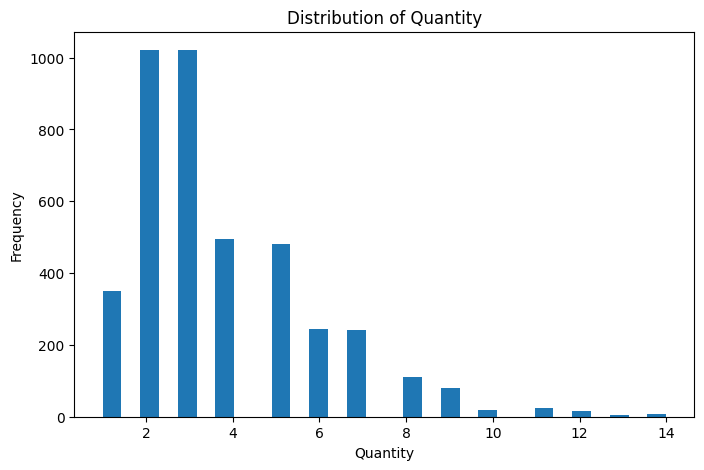

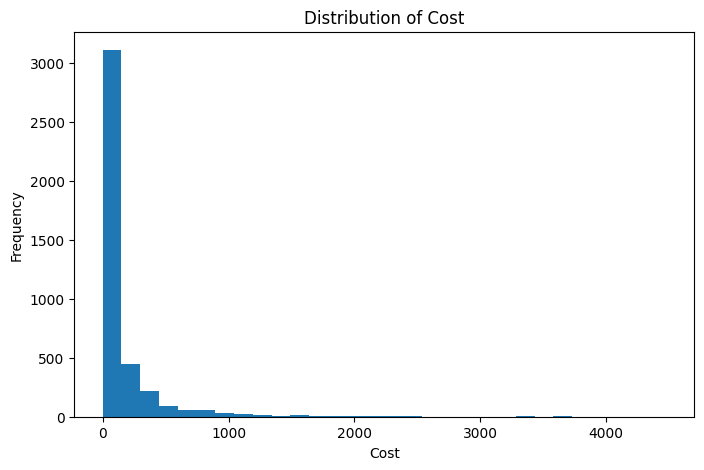

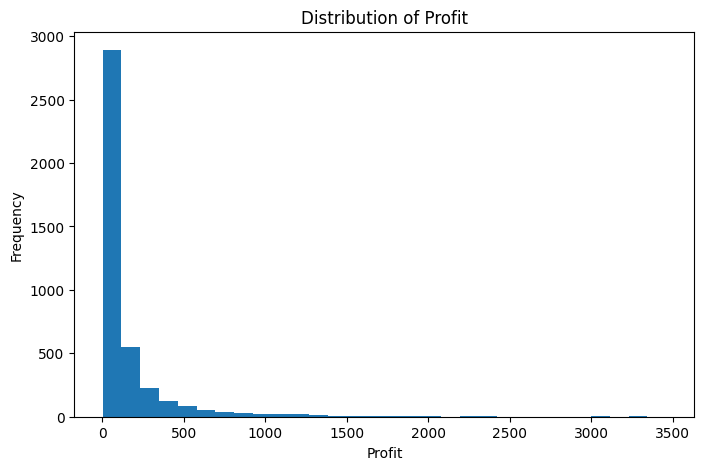

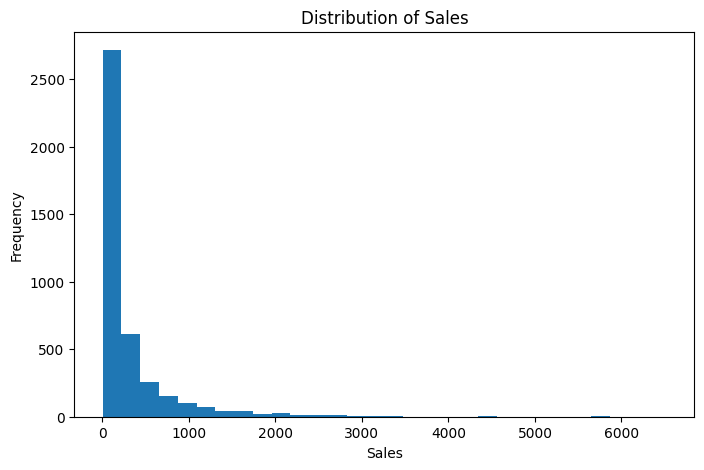

In [76]:
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

מההיסטוגרמות ניתן לראות כי המשתנים הכספיים אינם מתפלגים בצורה סימטרית. ברוב העסקאות ערכי המכירה, העלות והרווח נמוכים יחסית, אך קיימות עסקאות בעלות ערכים גבוהים מאוד. הדבר מתאים למאפיינים של חנות אונליין, שבה רוב הרכישות הן קטנות או בינוניות, אך מדי פעם מתבצעות עסקאות גדולות יותר.

### מציאת ערכים חריגים בשלוש שיטות

In [77]:
outlier_results = []

for col in numeric_cols:
    s = df[col]

    # IQR method
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    iqr_outliers = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

    # Z-score method
    z_scores = (s - s.mean()) / s.std()
    z_outliers = (np.abs(z_scores) > 3).sum()

    # Modified Z-score method using median MAD
    median = s.median()
    mad_median = np.median(np.abs(s - median))
    if mad_median == 0:
        modified_z_outliers = np.nan
    else:
        modified_z_scores = 0.6745 * (s - median) / mad_median
        modified_z_outliers = (np.abs(modified_z_scores) > 3.5).sum()

    outlier_results.append({
        "Variable": col,
        "IQR Outliers": int(iqr_outliers),
        "Z-Score Outliers": int(z_outliers),
        "Modified Z-Score Outliers": modified_z_outliers
    })

outlier_results_df = pd.DataFrame(outlier_results)
outlier_results_df

,Variable,IQR Outliers,Z-Score Outliers,Modified Z-Score Outliers
0,Quantity,71,53,152
1,Cost,486,84,631
2,Profit,468,104,618
3,Sales,467,100,609


#### ניתוח חריגים

נמצאו ערכים חריגים בכל המשתנים המספריים. עם זאת, לא כל ערך חריג הוא בהכרח טעות. בתחום המכירות, עסקה גדולה במיוחד יכולה להיות חריגה סטטיסטית אך עדיין אמיתית.

 לא מומלץ למחוק את החריגים באופן אוטומטי. עדיף לבחון אותם בהקשר העסקי: ייתכן שהם מייצגים רכישות גדולות, מוצרים יקרים או לקוחות משמעותיים.

### 5.2 משתנים קטגוריאליים

In [78]:
categorical_cols = [
    "Country", "Region", "Segment", "Category",
    "Ship Mode", "Sub-Category", "Product Name"
]

for col in categorical_cols:
    print("\n", col)
    display(df[col].value_counts().head(10).to_frame("Count"))
    display((df[col].value_counts(normalize=True).head(10) * 100).to_frame("Percent"))


 Country


,Count
Country,
France,991
Germany,805
United Kingdom,699
Italy,493
Spain,403
Netherlands,194
Austria,135
Sweden,100
Belgium,68


,Percent
Country,
France,24.08
Germany,19.56
United Kingdom,16.99
Italy,11.98
Spain,9.79
Netherlands,4.71
Austria,3.28
Sweden,2.43
Belgium,1.65



 Region


,Count
Region,
Central,2233
North,949
South,933


...

,Count
Sub-Category,
Art,747
Binders,542
Storage,386
Bookcases,361
Chairs,342
Furnishings,318
Appliances,175
Envelopes,162
Labels,162


,Percent
Sub-Category,
Art,18.15
Binders,13.17
Storage,9.38
Bookcases,8.77
Chairs,8.31
Furnishings,7.73
Appliances,4.25
Envelopes,3.94
Labels,3.94



 Product Name


,Count
Product Name,
"Sanford Pencil Sharpener, Water Color",16
"Boston Pencil Sharpener, Water Color",15
"BIC Markers, Easy-Erase",13
"Stanley Pencil Sharpener, Water Color",13
"Avery Binder, Clear",12
"Ibico Index Tab, Clear",11
"Binney & Smith Sketch Pad, Blue",11
"Sanford Pencil Sharpener, Easy-Erase",11
"Sanford Highlighters, Easy-Erase",11


,Percent
Product Name,
"Sanford Pencil Sharpener, Water Color",0.39
"Boston Pencil Sharpener, Water Color",0.36
"BIC Markers, Easy-Erase",0.32
"Stanley Pencil Sharpener, Water Color",0.32
"Avery Binder, Clear",0.29
"Ibico Index Tab, Clear",0.27
"Binney & Smith Sketch Pad, Blue",0.27
"Sanford Pencil Sharpener, Easy-Erase",0.27
"Sanford Highlighters, Easy-Erase",0.27


In [79]:
# כמה ערכים צריך כדי לתאר 80% מהדאטה בכל משתנה קטגוריאלי
p = 0.80
coverage_results = []

for col in categorical_cols:
    counts = df[col].value_counts(normalize=True).sort_values(ascending=False)
    cumulative = counts.cumsum()
    k_needed = (cumulative <= p).sum() + 1
    values_needed = counts.index[:k_needed].tolist()
    coverage_results.append({
        "Column": col,
        "K needed for 80%": k_needed,
        "Values": values_needed
    })

pd.DataFrame(coverage_results)

,Column,K needed for 80%,Values
0,Country,5,"[France, Germany, United Kingdom, Italy, Spain]"
1,Region,3,"[Central, North, South]"
2,Segment,2,"[Consumer, Corporate]"
3,Category,2,"[Office Supplies, Furniture]"
4,Ship Mode,3,"[Economy, Economy Plus, Priority]"
5,Sub-Category,10,"[Art, Binders, Storage, Bookcases, Chairs, Fur..."
6,Product Name,810,"[Sanford Pencil Sharpener, Water Color, Boston..."


In [80]:
# קטגוריות נדירות: ערכים שמופיעים פעם אחת בלבד
rare_results = []
for col in categorical_cols:
    counts = df[col].value_counts()
    rare_results.append({
        "Column": col,
        "Rare categories appearing once": int((counts == 1).sum())
    })

pd.DataFrame(rare_results)

,Column,Rare categories appearing once
0,Country,0
1,Region,0
2,Segment,0
3,Category,0
4,Ship Mode,0
5,Sub-Category,0
6,Product Name,491


#### ניתוח משתנים קטגוריאליים

המשתנים הקטגוריאליים מאפשרים להבין אילו מדינות, אזורים, סגמנטים, קטגוריות מוצרים ואופני משלוח נפוצים יותר בדאטה.
ר.
קטגוריות נדירות אינן בהכרח חסרות חשיבות. מוצר שנמכר מעט יכול עדיין להיות מוצר רווחי או מוצר חדש. לכן לא מומלץ למחוק קטגוריות נדירות באופן אוטומטי, אלא לבחון אותן לפי מטרת הניתוח.

במשתנים המספריים, המדדים המרכזיים כמו ממוצע אינם תמיד מייצגים היטב את הנתונים בגלל הטיה ימינה וערכים חריגים. לכן החציון מתאים יותר לתיאור עסקה טיפוסית. במשתנים קטגוריאליים, השכיחויות כן מספקות מידע חשוב על מבנה הדאטה.

## 6. קורלציות וקשרים

### 6.1 קשר מספרי-מספרי

In [81]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")
kendall_corr = df[numeric_cols].corr(method="kendall")

pearson_corr

,Quantity,Cost,Profit,Sales
Quantity,1.00,0.29,0.28,0.34
Cost,0.29,1.00,0.38,0.85
Profit,0.28,0.38,1.00,0.82
Sales,0.34,0.85,0.82,1.00


In [82]:
spearman_corr

,Quantity,Cost,Profit,Sales
Quantity,1.00,0.35,0.33,0.41
Cost,0.35,1.00,0.44,0.83
Profit,0.33,0.44,1.00,0.82
Sales,0.41,0.83,0.82,1.00


In [83]:
kendall_corr

,Quantity,Cost,Profit,Sales
Quantity,1.00,0.26,0.24,0.31
Cost,0.26,1.00,0.30,0.66
Profit,0.24,0.30,1.00,0.65
Sales,0.31,0.66,0.65,1.00


#### הסבר השוני בין Pearson, Spearman ו-Kendall

קורלציית Pearson בודקת קשר ליניארי בין משתנים מספריים. היא רגישה לערכים חריגים ולכן כאשר קיימות עסקאות גדולות במיוחד, הן עשויות להשפיע על התוצאה.

קורלציית Spearman בודקת קשר מונוטוני לפי דירוגים ולא לפי הערכים עצמם. לכן היא מתאימה יותר כאשר ההתפלגות אינה נורמלית או כאשר קיימים ערכים חריגים.

קורלציית Kendall גם היא מבוססת דירוגים, אך בדרך כלל נותנת ערכים נמוכים יותר. היא מתאימה כאשר רוצים לבדוק עד כמה הסדר בין הערכים עקבי.

מהקורלציות ניתן להסיק שקיים קשר חיובי חזק בין Sales לבין Cost, וכן בין Sales לבין Profit. הדבר הגיוני, משום שמכירה גבוהה יותר בדרך כלל כוללת גם עלות גבוהה יותר וגם רווח גבוה יותר.

הקשר בין Quantity לבין Sales קיים אך חלש יותר. המשמעות היא שכמות גבוהה יותר לא תמיד מובילה למכירה גבוהה יותר, משום שסכום המכירה תלוי גם במחיר המוצר ולא רק במספר היחידות שנרכשו.

### מטריצת קורלציה וגרפי פיזור

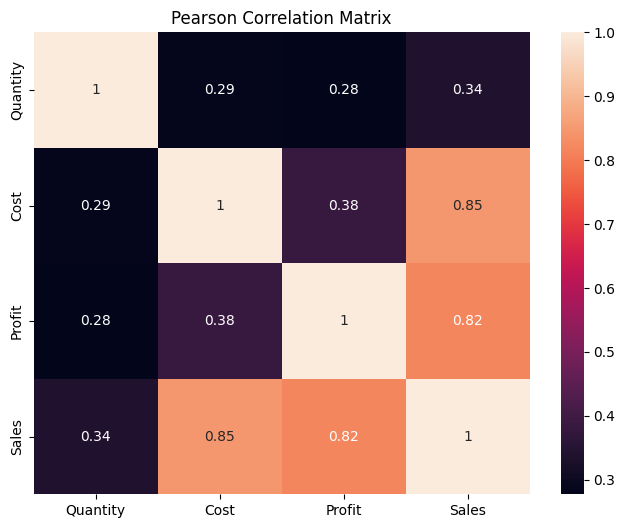

In [84]:
plt.figure(figsize=(8,6))
sns.heatmap(pearson_corr, annot=True)
plt.title("Pearson Correlation Matrix")
plt.show()

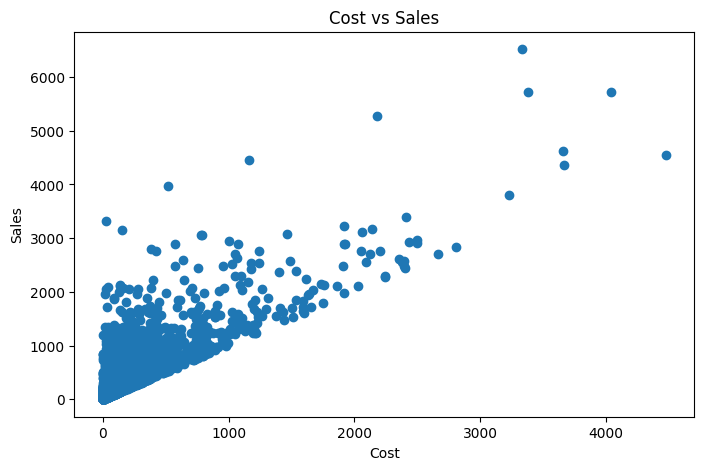

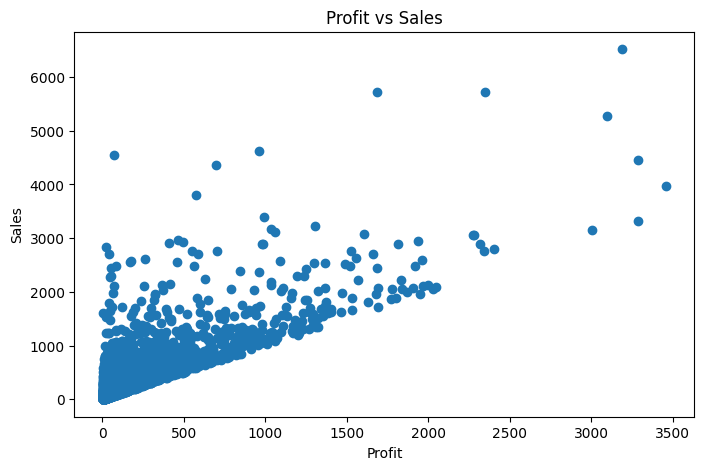

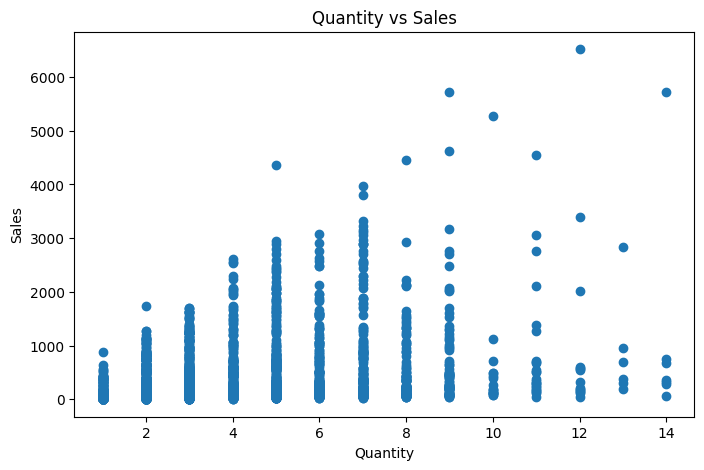

In [85]:
plt.figure(figsize=(8,5))
plt.scatter(df["Cost"], df["Sales"])
plt.title("Cost vs Sales")
plt.xlabel("Cost")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Profit"], df["Sales"])
plt.title("Profit vs Sales")
plt.xlabel("Profit")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Quantity"], df["Sales"])
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

גרפי הפיזור מחזקים את תוצאות הקורלציה. ניתן לראות שככל שהעלות והרווח עולים, גם המכירות נוטות לעלות. לעומת זאת, הקשר בין כמות לבין מכירות פחות חד משמעי, משום שעסקה עם מעט יחידות יכולה להיות יקרה אם מדובר במוצר בעל מחיר גבוה.

### 6.2 קשר קטגוריאלי-קטגוריאלי

In [86]:
# טבלאות שכיחות בין משתנים קטגוריאליים
pd.crosstab(df["Category"], df["Segment"])

Segment,Consumer,Corporate,Home Office
Category,,,
Furniture,573,334,169
Office Supplies,1323,800,472
Technology,236,133,75


In [87]:
pd.crosstab(df["Category"], df["Ship Mode"])

Ship Mode,Economy,Economy Plus,Immediate,Priority
Category,,,,
Furniture,655,213,54,154
Office Supplies,1498,544,146,407
Technology,290,81,17,56


In [88]:
pd.crosstab(df["Region"], df["Segment"])

Segment,Consumer,Corporate,Home Office
Region,,,
Central,1170,668,395
North,494,285,170
South,468,314,151


In [89]:
# טבלאות באחוזים לפי שורה
pd.crosstab(df["Category"], df["Segment"], normalize="index") * 100

Segment,Consumer,Corporate,Home Office
Category,,,
Furniture,53.25,31.04,15.71
Office Supplies,50.98,30.83,18.19
Technology,53.15,29.95,16.89


טבלאות השכיחות מאפשרות לראות כיצד קטגוריות שונות מתחלקות לפי משתנים אחרים. לדוגמה, ניתן לבדוק האם קטגוריית מוצרים מסוימת נפוצה יותר בקרב לקוחות פרטיים לעומת לקוחות עסקיים, או האם יש הבדל בשיטת המשלוח בין קטגוריות מוצרים.

חשוב להסתכל גם על אחוזים ולא רק על מספרים מוחלטים, משום שקטגוריה גדולה יותר תופיע יותר פעמים כמעט בכל חיתוך.

### בינינג וקשר בין משתנים קטגוריאליים למספריים

In [90]:
# חלוקת Sales לארבע קבוצות לפי רבעונים
# פעולה זו נעשית לצורך הבינינג שנדרש במטלה
sales_bin = pd.qcut(
    df["Sales"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

pd.crosstab(df["Category"], sales_bin, normalize="index") * 100

Sales,Low,Medium-Low,Medium-High,High
Category,,,,
Furniture,6.78,14.41,29.74,49.07
Office Supplies,36.57,32.25,21.93,9.25
Technology,2.03,7.88,31.98,58.11


#### מסקנה מהבינינג

ניתן לראות האם קטגוריות מסוימות נוטות להופיע יותר ברמות מכירה גבוהות או נמוכות.

### 6.3 גרפים

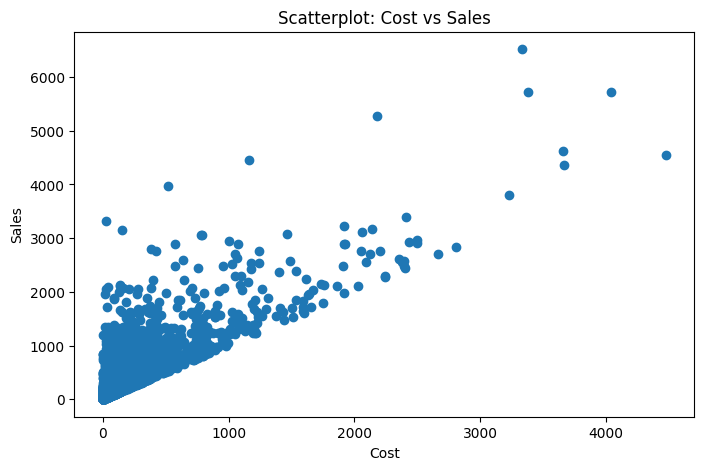

In [91]:
# Scatterplot
plt.figure(figsize=(8,5))
plt.scatter(df["Cost"], df["Sales"])
plt.title("Scatterplot: Cost vs Sales")
plt.xlabel("Cost")
plt.ylabel("Sales")
plt.show()

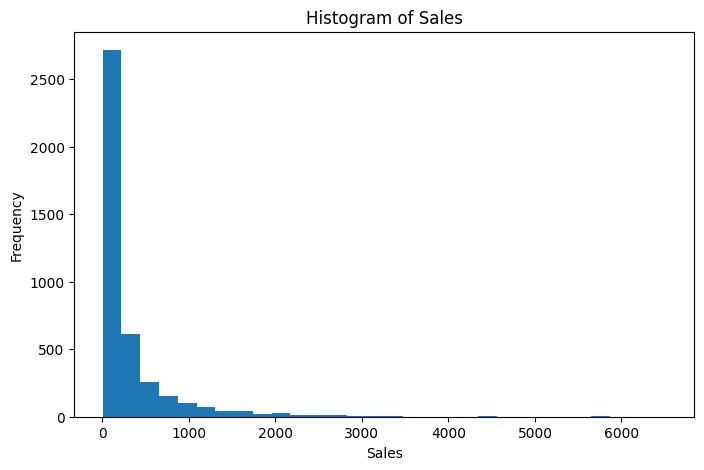

In [92]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Histogram of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

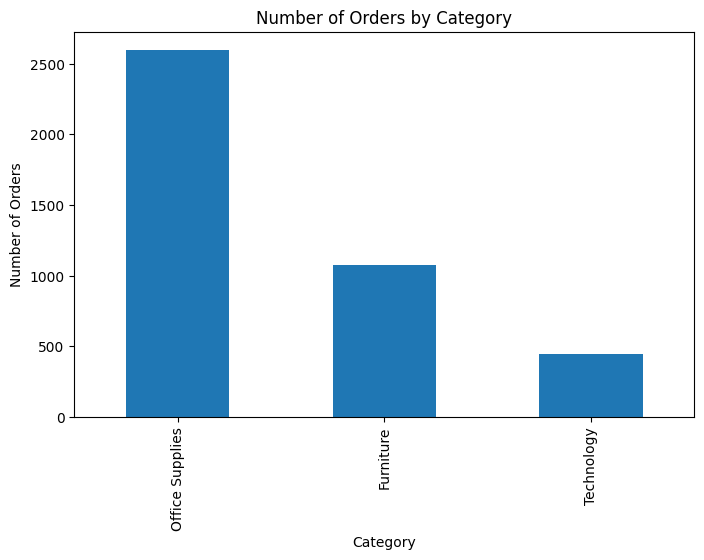

In [93]:
# Barchart
plt.figure(figsize=(8,5))
df["Category"].value_counts().plot(kind="bar")
plt.title("Number of Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()

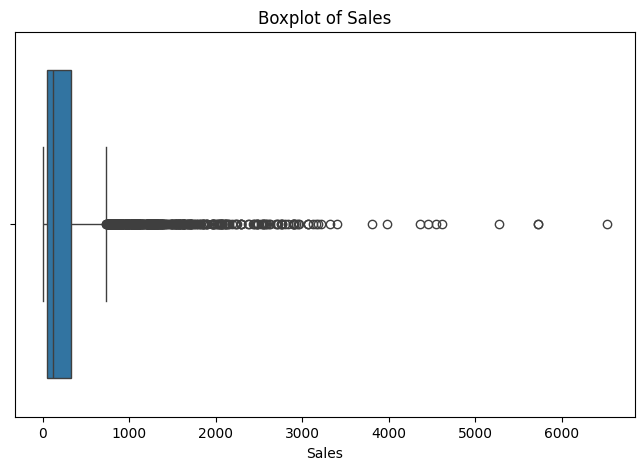

In [94]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Boxplot of Sales")
plt.xlabel("Sales")
plt.show()

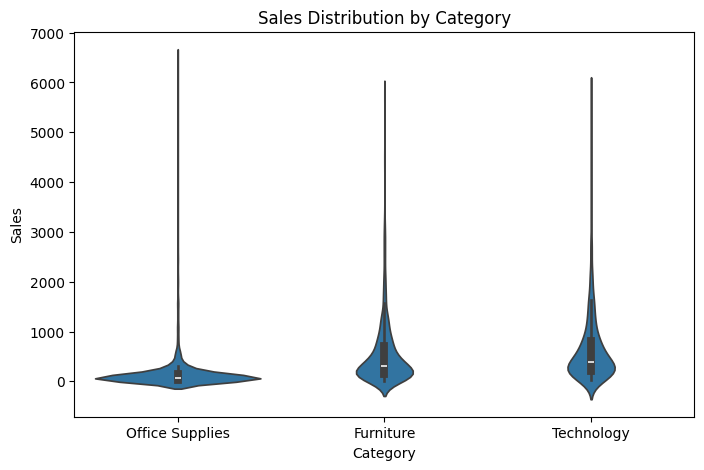

In [95]:
# Violin plot
plt.figure(figsize=(8,5))
sns.violinplot(x="Category", y="Sales", data=df)
plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

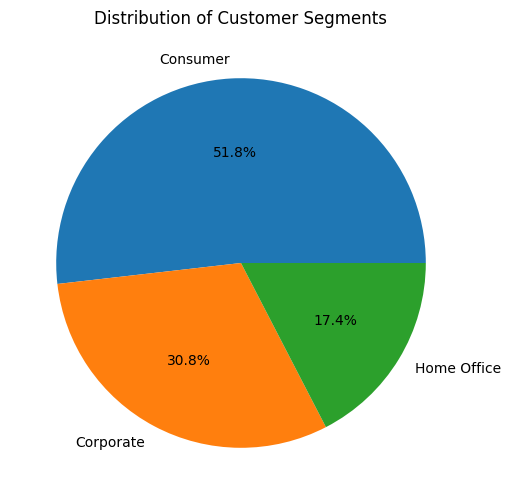

In [96]:
# Pie chart
plt.figure(figsize=(6,6))
df["Segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Customer Segments")
plt.ylabel("")
plt.show()

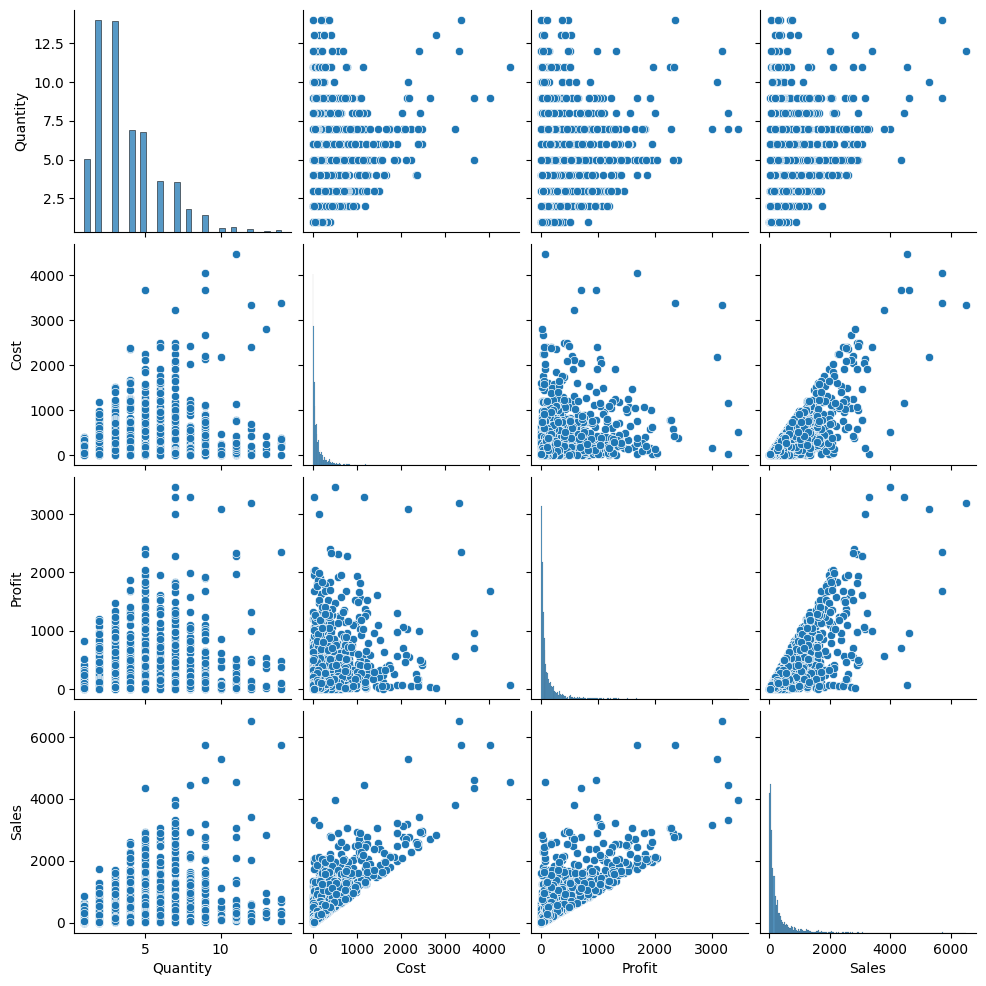

In [97]:
# Pairplot
sns.pairplot(df[numeric_cols])
plt.show()

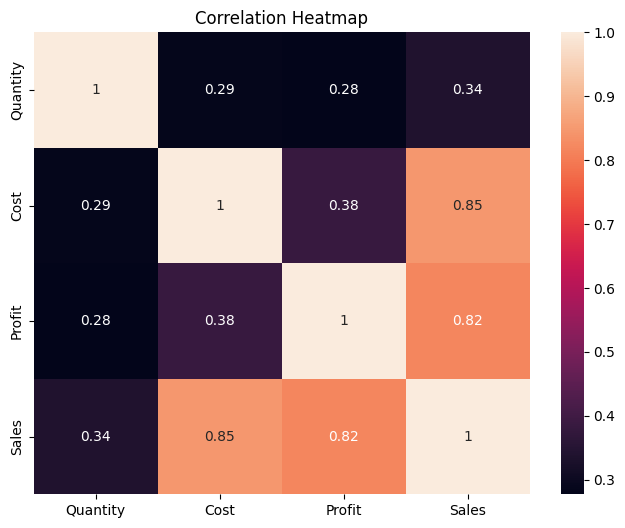

In [98]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### תובנות מהגרפים

הגרפים מצביעים על כך שמערך הנתונים אינו מאוזן לגמרי. קיימת דומיננטיות של קטגוריות מסוימות ושל סגמנטים מסוימים. בנוסף, התפלגות המכירות מוטה ימינה, כלומר רוב העסקאות הן בסכומים נמוכים או בינוניים, ומיעוט מהעסקאות הן בסכומים גבוהים מאוד.

## 7. ניתוח אינדקס

In [99]:
# האם האינדקס ייחודי?
df.index.is_unique

True

In [100]:
# האם עמודת התאריך ממוינת?
df["Order Date"].is_monotonic_increasing

True

In [101]:
# טווח תאריכים
df["Order Date"].min(), df["Order Date"].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2020-12-31 00:00:00'))

In [102]:
# ניתוח לפי שנים
annual_summary = df.groupby(df["Order Date"].dt.year)[["Sales", "Profit", "Quantity"]].sum()
annual_summary

,Sales,Profit,Quantity
Order Date,,,
2017,229391,111513,2802
2018,289555,153298,3558
2019,344917,173170,4101
2020,403701,188986,4959


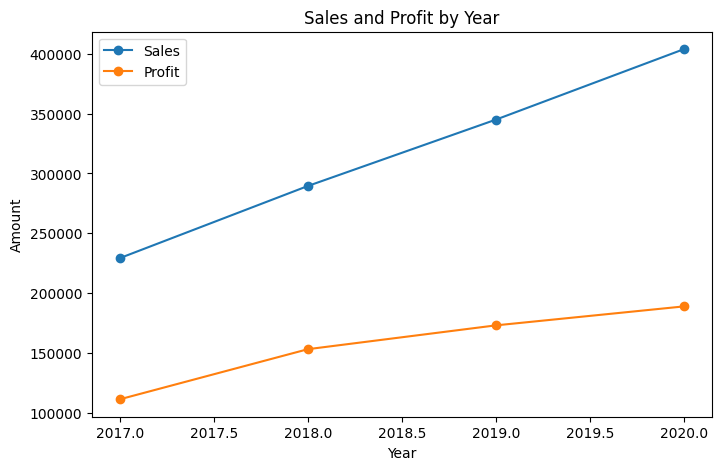

In [103]:
annual_summary[["Sales", "Profit"]].plot(kind="line", marker="o", figsize=(8,5))
plt.title("Sales and Profit by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.show()

#### סיכום ניתוח האינדקס

האינדקס הטכני של pandas ייחודי, אך אינו בעל משמעות עסקית. הוא לא מייצג זמן, לקוח או הזמנה.

עמודת Order Date היא משתנה הזמן המרכזי, והיא מאפשרת לבחון מגמות לאורך זמן. הנתונים ממוינים כרונולוגית לפי התאריך, ולכן ניתן לבצע ניתוח לפי שנים.

מהניתוח השנתי ניתן לבדוק האם קיימת מגמת עלייה או ירידה במכירות, ברווח ובכמות. עם זאת, יש להיזהר ממסקנות חד-משמעיות, משום שאין מידע חיצוני על שינויים בשיווק, מחירים, מלאי או מספר לקוחות.

## 8. תובנות וסיפור הנתונים

### תובנה מרכזית 1: הפעילות אינה מפוזרת באופן שווה

הנתונים מראים שרוב הפעילות מרוכזת בחלק מהמדינות, האזורים והקטגוריות. המשמעות היא שהדאטה אינו מאוזן לחלוטין, ולכן מסקנות עסקיות עשויות להיות מושפעות בעיקר מהקבוצות הדומיננטיות.

### תובנה מרכזית 2: שכיחות אינה בהכרח שווה להכנסה גבוהה

קטגוריה יכולה להופיע בהרבה הזמנות, אך לא בהכרח לייצר את המכירות הגבוהות ביותר לכל עסקה. לכן חשוב לא להסתפק בספירת רשומות בלבד, אלא לבחון גם מכירות, רווח ועלות.

### תובנה מרכזית 3: ערכים חריגים יכולים להיות מידע חשוב

במשתנים המספריים נמצאו ערכים חריגים לפי כמה שיטות. עם זאת, בתחום מכירות אונליין ערכים חריגים אינם בהכרח טעויות. ייתכן שמדובר בהזמנות גדולות, מוצרים יקרים או לקוחות משמעותיים.

### הטיה או סיכון אפשרי

הטיה מרכזית במערך הנתונים היא ריכוז גבוה של רשומות בקבוצות מסוימות. אם רוב הנתונים מגיעים ממדינות, אזורים או קטגוריות מסוימים, המסקנות עשויות להתאים בעיקר אליהם ולא לכלל השוק.

בנוסף, העובדה שאין ערכים חסרים כלל יכולה לרמוז שהנתונים עברו ניקוי מוקדם. אם זה נכון, ייתכן שחלק מהבעיות המקוריות בדאטה כבר הוסרו, ולכן הנתונים אינם משקפים באופן מלא מערכת תפעולית גולמית.

### נקודות כשל אפשריות למודלי ML

אם בעתיד נרצה להשתמש בנתונים לצורך מודל ML, קיימות כמה נקודות כשל אפשריות:

1. משתנים עם קרדינליות גבוהה, כמו Product Name, City ו-Customer Name, עלולים ליצור התאמת יתר או קושי בהכללה.
2. ערכים חריגים במשתנים הכספיים עלולים להשפיע על מודלים רגישים לערכים קיצוניים.
3. הטיה גאוגרפית או קטגוריאלית עלולה לגרום למודל ללמוד בעיקר את הדפוסים של הקבוצות הדומיננטיות.
4. רשומות שבהן Cost שווה ל-0 עלולות לפגוע בניתוח רווחיות או במודל שמנסה לחזות רווח.

### מה למדתי מהניתוח?

מהניתוח ניתן ללמוד כי נתונים יכולים להיראות מסודרים ושלמים מבחינה טכנית, אך עדיין לכלול שאלות חשובות לגבי משמעותם. העובדה שאין ערכים חסרים אינה בהכרח אומרת שהנתונים מושלמים, אלא ייתכן שהם עברו ניקוי. בנוסף, ערכים חריגים אינם בהכרח טעויות, אלא עשויים לייצג פעילות עסקית חשובה.

עוד ניתן ללמוד כי בניתוח נתונים חשוב להבחין בין כמות הופעות לבין תרומה כספית. קטגוריה נפוצה אינה בהכרח הקטגוריה שמייצרת את העסקאות הגבוהות ביותר.

## סיכום העבודה

במסגרת העבודה נותח מערך נתונים של מכירות אונליין הכולל 4115 שורות ו-16 עמודות. הנתונים כוללים מידע על הזמנות, לקוחות, מדינות, אזורים, קטגוריות מוצרים, סוגי משלוח, כמויות, עלויות, רווחים ומכירות.

בשלב המטא-אנליזה נמצא כי הנתונים עומדים בדרישות המטלה וכוללים שילוב של משתנים מספריים, קטגוריאליים ומשתנה זמן. בבדיקת איכות הנתונים נמצא כי אין ערכים חסרים ואין כפילויות, אך קיימות רשומות שבהן Cost שווה ל-0, ולכן מדובר בערך חשוד שיש לבחון בזהירות.

בניתוח החד-משתני נמצא כי המשתנים הכספיים מוטים ימינה, כלומר רוב העסקאות הן בסכומים נמוכים או בינוניים, אך קיימות עסקאות גדולות מאוד. בנוסף, נמצאו ערכים חריגים בכל המשתנים המספריים לפי שלוש שיטות שונות.

בניתוח הקשרים נמצא קשר חיובי בין Sales, Cost ו-Profit, וקשר חלש יותר בין Quantity לבין Sales. משמעות הדבר היא שסכום המכירה מושפע לא רק מכמות המוצרים אלא גם מסוג המוצר וממחירו.

לסיכום, הנתונים מאפשרים להבין דפוסי מכירה מרכזיים בחנות אונליין, אך יש להתייחס בזהירות להטיות, לערכים חריגים ולמגבלות הנובעות מחוסר מידע על אופן איסוף הנתונים.